In [1]:
import logging
import os

logging.basicConfig(level=logging.INFO)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget


import tanglepack
from tanglepack import TangleSession
import inspect
from tanglepack.numerics.ManifoldMachine import ManifoldMachine
print(tanglepack.__file__)
print(hasattr(ManifoldMachine, "_strictify_increasing"))
src = inspect.getsource(ManifoldMachine._refine_layer)
print("representable" in src)
# Declare up-front whether this run should use the GPU. Enabling it only changes
# where the batched map is evaluated; the rest of the pipeline is untouched.
# USE_GPU = os.environ.get("TANGLEPACK_GPU", "0") == "1"
USE_GPU = "1"

/home/dezhu/Development/TanglePack/tangle-pack/src/tanglepack/__init__.py
False
False


In [2]:
def henon_map(point):
    k, b = 2.8, 1
    x, y = point
    return np.stack([y - k + x**2, -b * x], axis=0)


def henon_map_inverse(point):
    k, b = 2.8, 1
    x, y = point
    return np.stack([-y / b, x + k - (y**2) / (b**2)], axis=0)


def henon_jacobian(point):
    k, b = 2.8, 1
    x, y = point
    return np.array([[2 * x, 1], [-b, 0]])

In [3]:
session = TangleSession(henon_map, henon_map_inverse, henon_jacobian)

In [4]:
if USE_GPU:
    try:
        tanglepack.enable_gpu(session)
        print("GPU acceleration enabled for the batched map evaluations.")
    except ImportError as exc:
        print(f"GPU requested but unavailable ({exc}); continuing on the CPU.")

INFO:tanglepack.numerics.gpu:GPU acceleration enabled for system 'unnamed' (min_batch_points=64).


GPU acceleration enabled for the batched map evaluations.


In [ ]:
session.workbench._man_machine.area_cutoff = 1e-7
fp3 = session.construct_fixed_point([[0, 1], [-1, 0], [-1, 1]])
session.orient_eigenvectors(
    fp3, {"unstable": np.array([0, 1]), "stable": np.array([1, 1])}
)
session.initialize_both_manifolds(fp3)

({(0, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c9363340>,
  (1, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c93628c0>,
  (2, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c9362890>},
 {(0, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c9362aa0>,
  (2, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c93627d0>,
  (1, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c93627a0>})

In [6]:
session.workbench._man_machine.area_cutoff = 1e-7
fp1 = session.construct_fixed_point([4, -4])
session.orient_eigenvectors(
    fp1, {"unstable": np.array([-1, 0]), "stable": np.array([0, 1])}
)
session.initialize_both_manifolds(fp1)

({(0, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c9362680>},
 {(0, 0): <tanglepack.numerics.BaseManifold.BaseManifold at 0x7900c9361c00>})

In [7]:
# The inner unstable arm [0, 1] is bounded through 4 iterates and then escapes
# to infinity on the 5th (per-step unstable eigenvalue ~4.0 at k=2.1, so the arm
# leaves the trapping region quickly). Keep it at 4. The stable arm stays bounded
# much longer.
session.grow_n_times(fp3, "unstable", num_iterations=5)
session.grow_n_times(fp3, "stable", num_iterations=5)

In [8]:
session.grow_n_times(fp1, "unstable", num_iterations=9)
session.grow_n_times(fp1, "stable", num_iterations=8)

In [9]:
session.compute_intersections([fp3, fp1])
session.trim_stable_manifolds(fp3)
session.trim_stable_manifolds(fp1)
session.create_bridges(fp3)
session.create_bridges(fp1)
session.infer_iterate_table()



0

In [10]:
T1 = session.trellis(fp1)
T1.classify_strong_pips()

[0, 2, 6]

In [11]:
T3 = session.trellis(fp3)
T3.classify_strong_pips()

[0, 6]

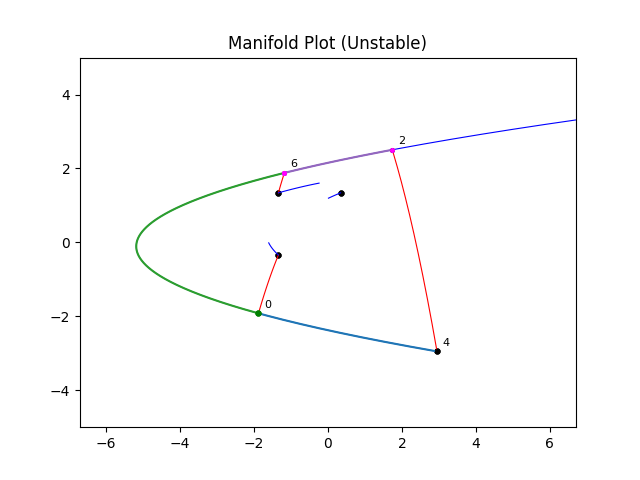

In [12]:
plt.figure()

for fp in (fp3, fp1):
    session.workbench.plot_tangle(fp, "stable", color="r", linewidth=0.8)
    session.workbench.plot_tangle(fp, "unstable", color="b", linewidth=0.8)

session.workbench.plot_all_bridges()
session.workbench.plot_intersections(fp1, show_ids=True)
T3.plot_strong_pip_candidates()
T3.plot_strong_pip(s=12)
T1.plot_strong_pip_candidates()
T1.plot_strong_pip(s=12)
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.show()

In [ ]:
# T1.set_strong_pip(15)
session.add_resonance_zones([T1.strong_pip, T3.strong_pip])

In [ ]:
small_zone = min(session.resonance_zones.values(), key=lambda z: z.area)
large_zone = max(session.resonance_zones.values(), key=lambda z: z.area)

result_small = session.blast_zone(
    small_zone, num_iterations=14, fixed_point=[fp1, fp3], min_separation=1e-4
)
result_large = session.blast_zone(
    large_zone, num_iterations=12, fixed_point=[fp1, fp3], min_separation=1e-3
)

In [ ]:
plt.figure()

for fp in (fp3, fp1):
    session.workbench.plot_tangle(fp, "stable", color="r", linewidth=0.8)

session.workbench.plot_all_bridges()
T3.plot_strong_pip_candidates()
T3.plot_strong_pip(s=12)
T1.plot_strong_pip_candidates()
T1.plot_strong_pip(s=12)
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.show()